In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df=pd.read_csv("International_T20_Data.csv")

In [ ]:
df.shape

(1417, 27)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1417 entries, 0 to 1416
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   innings                      1417 non-null   object 
 1   meta.data_version            1417 non-null   float64
 2   meta.created                 1417 non-null   object 
 3   meta.revision                1417 non-null   int64  
 4   info.dates                   1417 non-null   object 
 5   info.gender                  1417 non-null   object 
 6   info.match_type              1417 non-null   object 
 7   info.outcome.by.wickets      651 non-null    float64
 8   info.outcome.winner          1372 non-null   object 
 9   info.overs                   1417 non-null   int64  
 10  info.player_of_match         1255 non-null   object 
 11  info.teams                   1417 non-null   object 
 12  info.toss.decision           1417 non-null   object 
 13  info.toss.winner  

In [ ]:
df.describe()

,meta.data_version,meta.revision,info.outcome.by.wickets,info.overs,info.outcome.by.runs,info.match_type_number,info.neutral_venue
count,1.417000e+03,1417.000000,651.000000,1417.000000,721.000000,684.000000,328.0
mean,9.000000e-01,1.370501,6.476190,20.063514,39.088766,748.774854,1.0
std,5.108829e-15,0.575198,1.987802,1.379399,33.385757,190.050264,0.0
min,9.000000e-01,1.000000,1.000000,20.000000,1.000000,380.000000,1.0
25%,9.000000e-01,1.000000,5.000000,20.000000,13.000000,627.000000,1.0
50%,9.000000e-01,1.000000,7.000000,20.000000,30.000000,746.500000,1.0
75%,9.000000e-01,2.000000,8.000000,20.000000,56.000000,883.250000,1.0
max,9.000000e-01,5.000000,10.000000,50.000000,249.000000,1104.000000,1.0


In [ ]:
df.head()

,innings,meta.data_version,meta.created,meta.revision,info.dates,info.gender,info.match_type,info.outcome.by.wickets,info.outcome.winner,info.overs,...,info.outcome.by.runs,info.match_type_number,info.neutral_venue,info.outcome.method,info.outcome.result,info.outcome.eliminator,info.supersubs.New Zealand,info.supersubs.South Africa,info.bowl_out,info.outcome.bowl_out
0,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-18,2,"[datetime.date(2017, 2, 17)]",male,T20,5.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-19,2,"[datetime.date(2017, 2, 19)]",male,T20,2.0,Sri Lanka,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[{'1st innings': {'team': 'Australia', 'delive...",0.9,2017-02-23,1,"[datetime.date(2017, 2, 22)]",male,T20,NaN,Australia,20,...,41.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[{'1st innings': {'team': 'Hong Kong', 'delive...",0.9,2016-09-12,1,"[datetime.date(2016, 9, 5)]",male,T20,NaN,Hong Kong,20,...,40.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[{'1st innings': {'team': 'Zimbabwe', 'deliver...",0.9,2016-06-19,1,"[datetime.date(2016, 6, 18)]",male,T20,NaN,Zimbabwe,20,...,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# (1) Rename all the column names to their appropriate names, for example meta.created should be renamed as created_date

In [ ]:
df = df.rename(columns={
    "innings": "innings_data",
    "meta.data_version": "data_version",
    "meta.created": "created_date",
    "meta.revision": "revision_number",
    "info.dates": "match_dates",
    "info.gender": "gender",
    "info.match_type": "match_type",
    "info.match_type_number": "match_number",
    "info.overs": "total_overs",
    "info.teams": "teams",
    "info.city": "city",
    "info.venue": "venue",
    "info.umpires": "umpires",
    "info.player_of_match": "player_of_match",
    "info.toss.decision": "toss_decision",
    "info.toss.winner": "toss_winner",
    "info.outcome.winner": "match_winner",
    "info.outcome.by.runs": "win_by_runs",
    "info.outcome.by.wickets": "win_by_wickets",
    "info.outcome.method": "result_method",
    "info.outcome.result": "result",
    "info.outcome.eliminator": "eliminator",
    "info.outcome.bowl_out": "bowl_out",
    "info.neutral_venue": "neutral_venue",
    "info.supersubs.New Zealand": "supersub_new_zealand",
    "info.supersubs.South Africa": "supersub_south_africa",
    "info.bowl_out": "bowl_out_details"
})

print(df.columns)

Index(['innings_data', 'data_version', 'created_date', 'revision_number',
       'match_dates', 'gender', 'match_type', 'win_by_wickets', 'match_winner',
       'total_overs', 'player_of_match', 'teams', 'toss_decision',
       'toss_winner', 'umpires', 'venue', 'city', 'win_by_runs',
       'match_number', 'neutral_venue', 'result_method', 'result',
       'eliminator', 'supersub_new_zealand', 'supersub_south_africa',
       'bowl_out_details', 'bowl_out'],
      dtype='object')


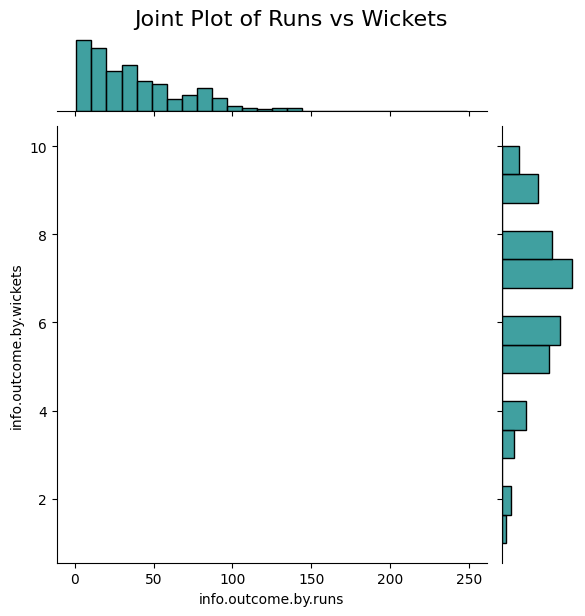

In [ ]:
sns.jointplot(
    data=df,
    x='info.outcome.by.runs',
    y='info.outcome.by.wickets',
    kind='scatter',
    color='teal'
)
plt.suptitle("Joint Plot of Runs vs Wickets", y=1.02, fontsize=16)
plt.show()


### **(2) Find** **out** **the** **top** **three** **venues** **which** **hosted** **the** **greatest** **number** **of** **matches**.

In [ ]:
top_venues = df['venue'].value_counts().head(3)
print("Top 3 venues with the greatest number of matches:")
print(top_venues)


Top 3 venues with the greatest number of matches:
venue
Dubai International Cricket Stadium    62
Sheikh Zayed Stadium                   41
Shere Bangla National Stadium          39
Name: count, dtype: int64


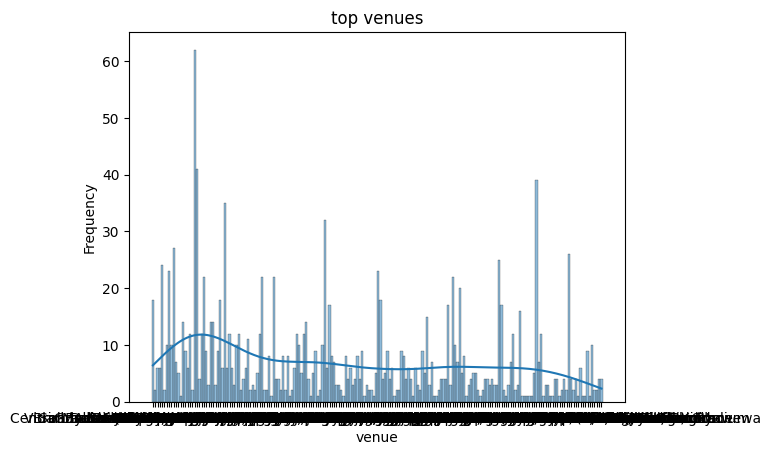

In [ ]:
sns.histplot(df['venue'],kde=True,bins=20)
plt.title('top venues')
plt.xlabel('venue')
plt.ylabel('Frequency')
plt.show()

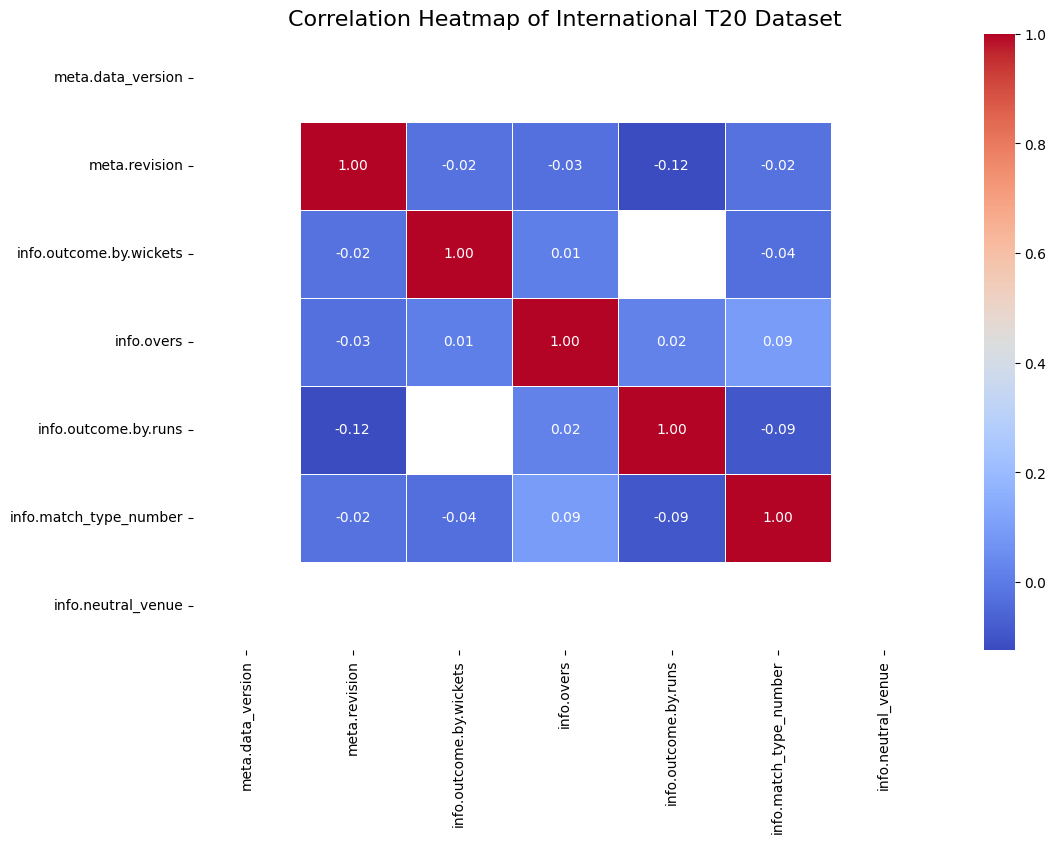

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])
corr = numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of International T20 Dataset", fontsize=16)
plt.show()


### **(3) Find** **out** **the** **pair of cricket teams who played the most number of T20 matches against each other.** **bold text**

In [ ]:
import pandas as pd
import ast

df = pd.read_csv("International_T20_Data.csv")

df["info.teams"] = df["info.teams"].apply(ast.literal_eval)
pairs = df["info.teams"].apply(lambda x: tuple(sorted(x)))
most_played = pairs.value_counts().idxmax()

print("Teams who played most matches:", most_played)
print("Number of matches played:", pairs.value_counts().max())

Teams who played most matches: ('Australia', 'England')
Number of matches played: 45


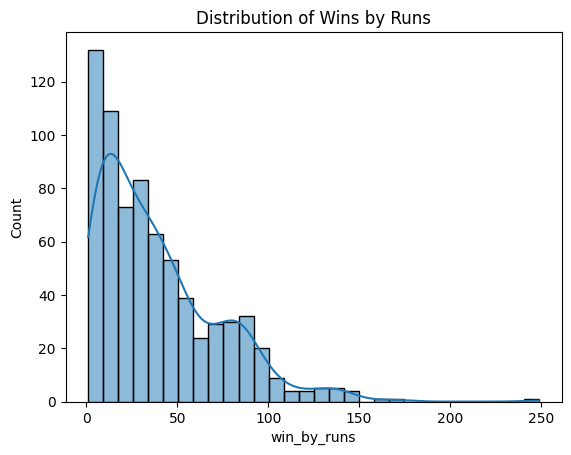

In [ ]:
sns.histplot(df['win_by_runs'], bins=30, kde=True)
plt.title("Distribution of Wins by Runs")
plt.show()


### **(4) Print the top five teams by their win percentages. Win percentage is defined as the number of matches won divided by the number of matches played and then multiplied by 100.**

In [ ]:
import pandas as pd
import ast

df = pd.read_csv("International_T20_Data.csv")
df['info.teams'] = df['info.teams'].apply(ast.literal_eval)
matches_played = df['info.teams'].explode().value_counts()
matches_won = df['info.outcome.winner'].value_counts()
stats = pd.DataFrame({
    'Matches_Played': matches_played,
    'Matches_Won': matches_won
}).fillna(0)

stats['Win_Percentage'] = (stats['Matches_Won'] / stats['Matches_Played']) * 100
top_5 = stats.sort_values('Win_Percentage', ascending=False).head(5)
print(top_5)

             Matches_Played  Matches_Won  Win_Percentage
Belgium                   3          3.0      100.000000
Spain                     6          5.0       83.333333
Germany                  17         13.0       76.470588
Namibia                  34         25.0       73.529412
Afghanistan              75         51.0       68.000000


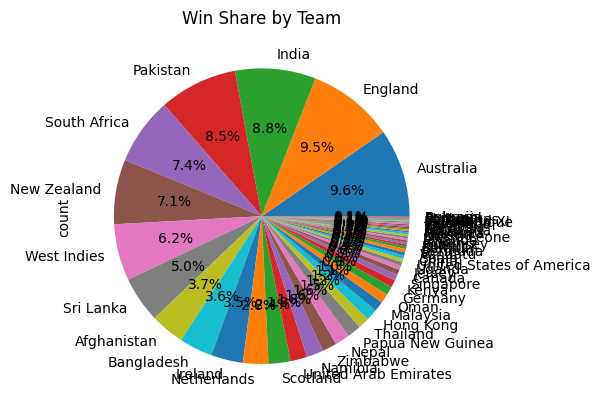

In [ ]:
team_wins = df['match_winner'].value_counts()
team_wins.plot(kind='pie', autopct='%1.1f%%')
plt.title("Win Share by Team")
plt.show()


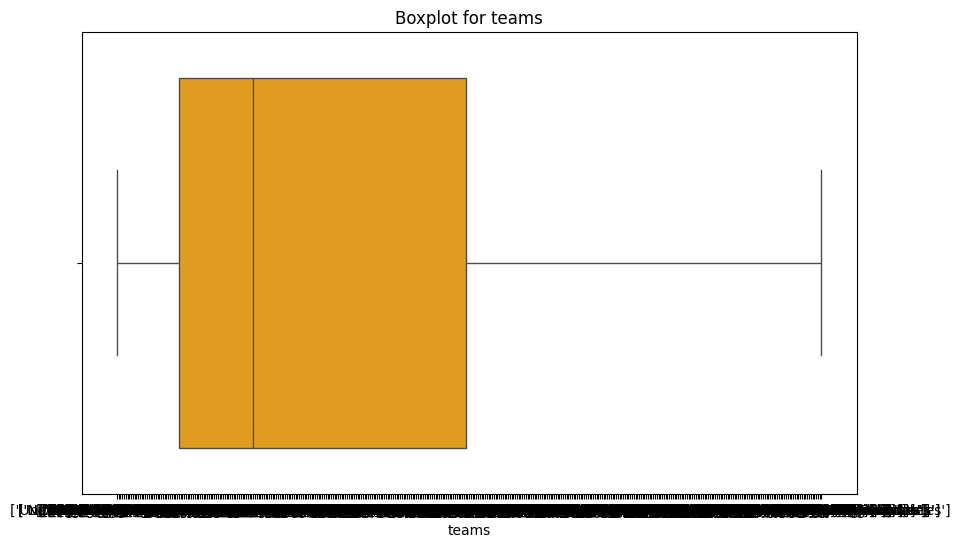

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['info.teams'], color='orange')
plt.title('Boxplot for teams')
plt.xlabel('teams')
plt.show()

## **(5) Write a function to get the scorecard of each match. This function would take the innings value as argument and return two scorecard dataframes each for one team as shown below. So the first dataframe would contain the top 4 scorers of the team who batted first and the top 4 bowlers of the opponent team. And the second dataframe would contain the top 4 scorers of the team who batted second and the top 4 bowlers of the opponent team.**

In [ ]:
import pandas as pd
import ast
df = pd.read_csv("International_T20_Data.csv")
df["innings"] = df["innings"].apply(ast.literal_eval)

def get_scorecard(innings):
    result = []

    for inn in innings:
        deliveries = list(inn.values())[0]["deliveries"]
        bat, bowl = {}, {}

        for ball in deliveries:
            info = list(ball.values())[0]
            bat[info["batsman"]] = bat.get(info["batsman"], 0) + info["runs"]["batsman"]
            b = info["bowler"]
            bowl.setdefault(b, {"runs":0, "wkts":0})
            bowl[b]["runs"] += info["runs"]["total"]
            if "wicket" in info:
                bowl[b]["wkts"] += 1

        bat_df = pd.DataFrame(bat.items(), columns=["Player","Runs"])\
                   .sort_values("Runs", ascending=False).head(4)
        bowl_df = pd.DataFrame(
            [(k,v["wkts"],v["runs"]) for k,v in bowl.items()],
            columns=["Bowler","Wickets","Runs_Conceded"]
        ).sort_values(["Wickets","Runs_Conceded"],
                      ascending=[False,True]).head(4)

        result.append((bat_df, bowl_df))

    return result

In [ ]:
score = get_scorecard(df["innings"].iloc[0])

# First innings
print(score[0][0])  # Top 4 batters
print(score[0][1])  # Top 4 bowlers

#second innings
print(score[1][0])
print(score[1][1])

      Player  Runs
0   AJ Finch    43
1  M Klinger    38
2    TM Head    31
4  AJ Turner    18
           Bowler  Wickets  Runs_Conceded
0      SL Malinga        2             29
5   DAS Gunaratne        1             11
4  PADLR Sandakan        1             31
2   JRMVB Sanjaya        1             35
            Player  Runs
3    DAS Gunaratne    52
2   EMDY Munaweera    44
0      N Dickwella    30
4  TAM Siriwardana    15
        Bowler  Wickets  Runs_Conceded
5    AJ Turner        2             12
4      A Zampa        2             26
0   PJ Cummins        1             30
2  JP Faulkner        0             29


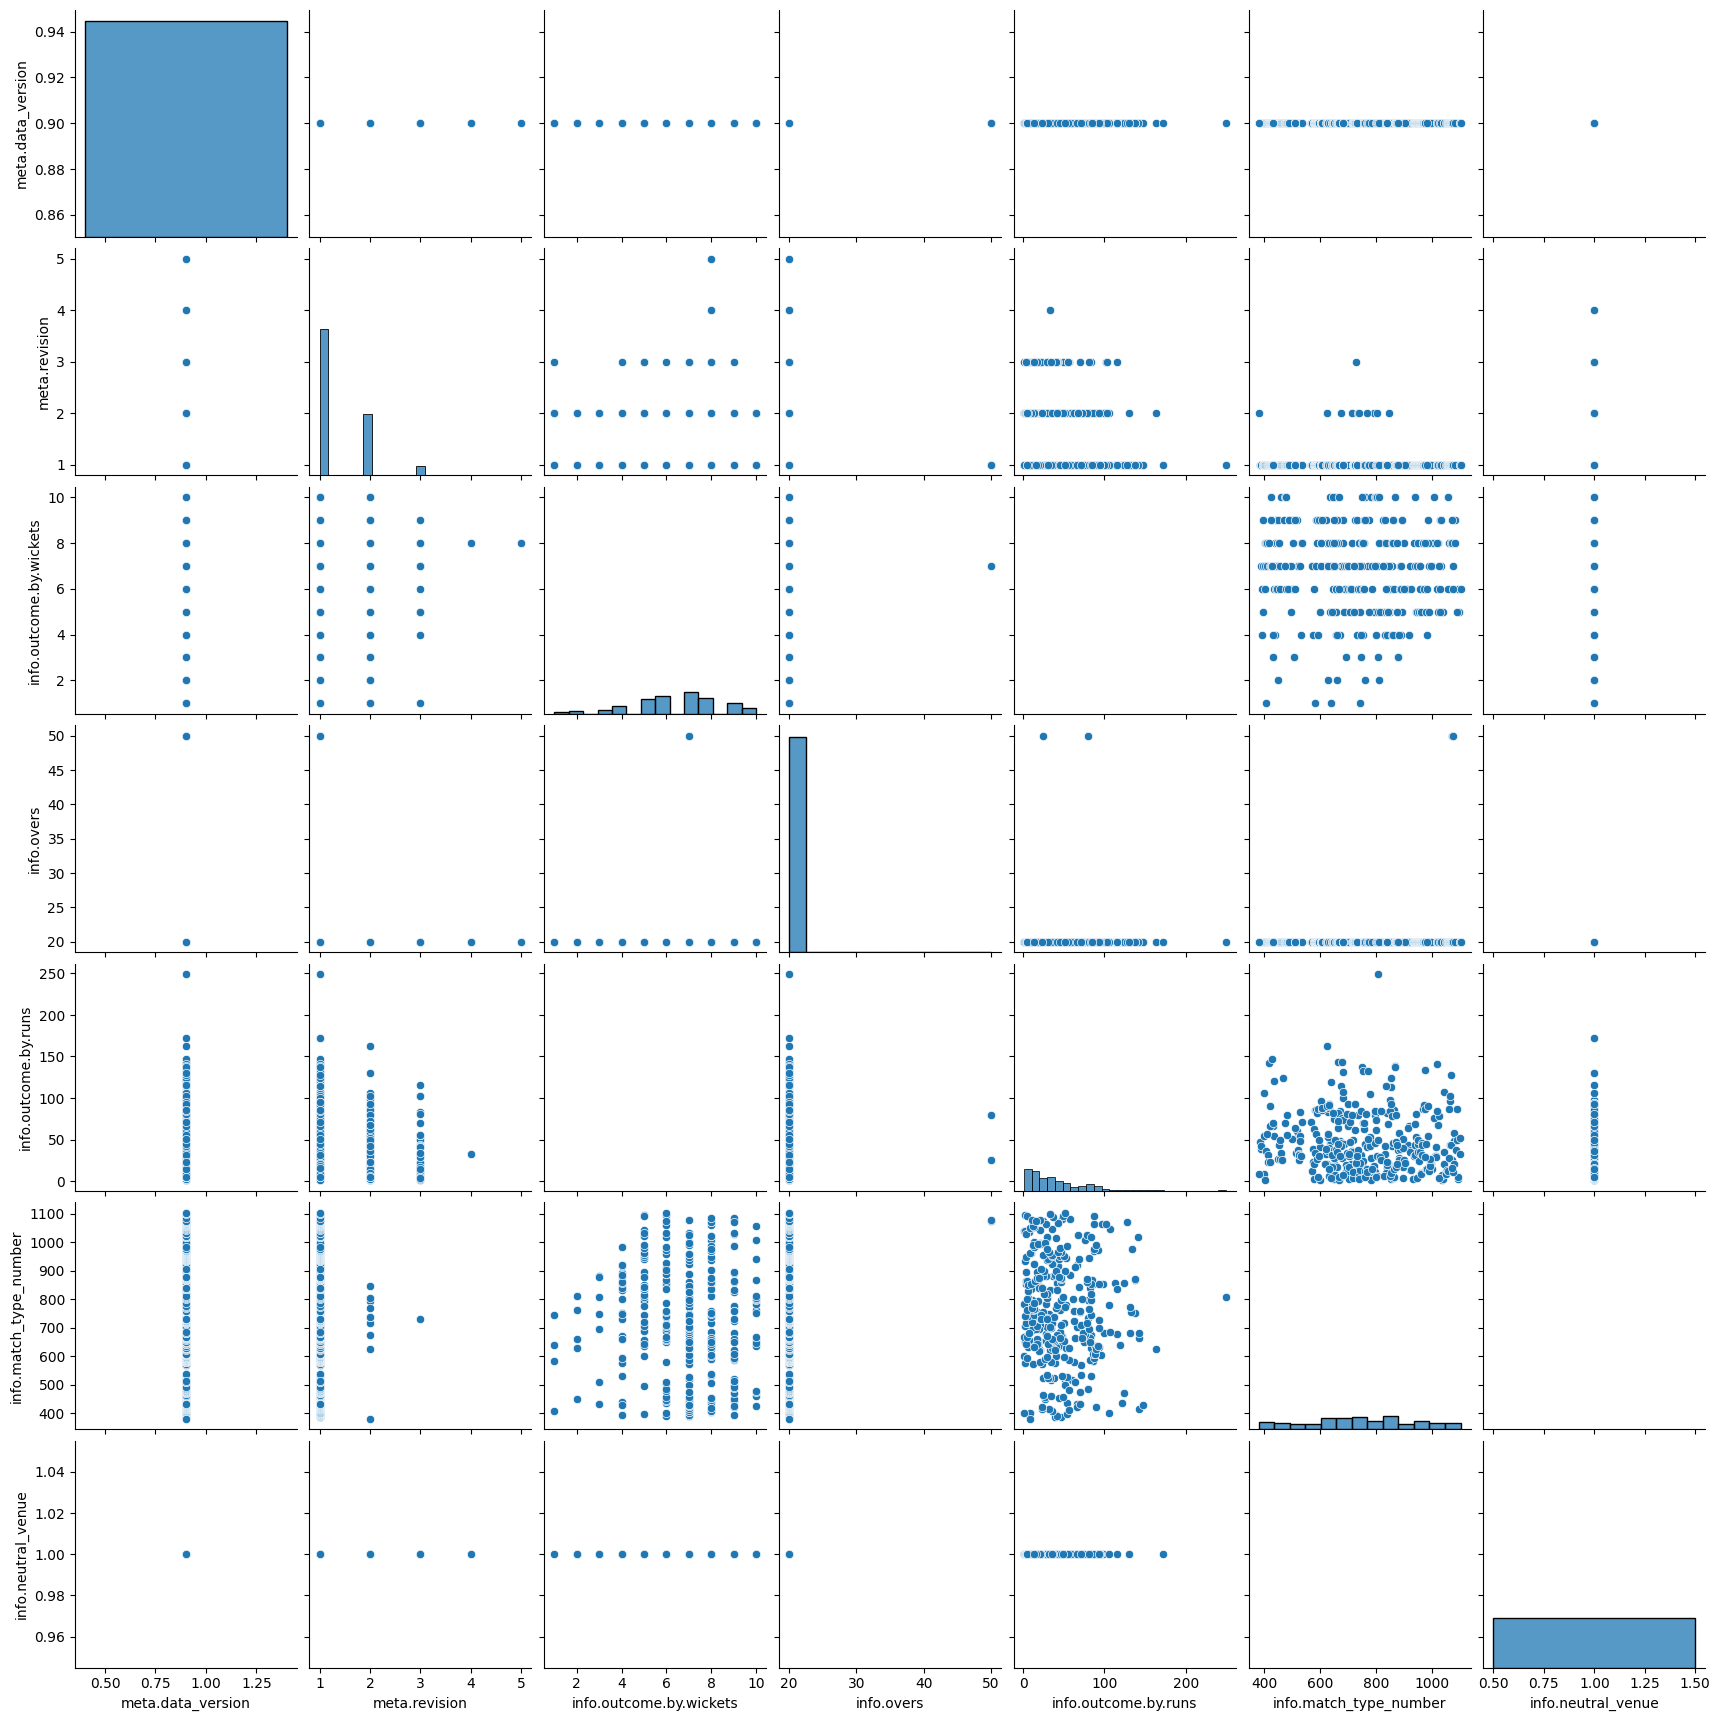

In [ ]:
sns.pairplot(df)
plt.show()


/tmp/ipykernel_524/96790265.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='info.outcome.winner', y='info.outcome.by.wickets', data=df, palette='Set3')


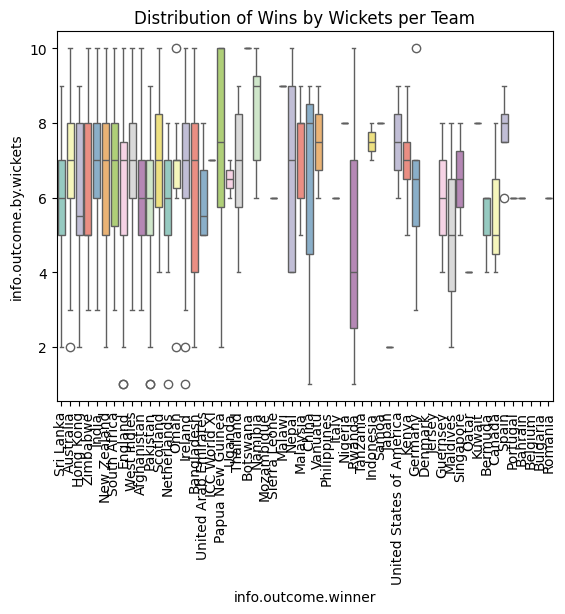

In [ ]:
sns.boxplot(x='info.outcome.winner', y='info.outcome.by.wickets', data=df, palette='Set3')
plt.xticks(rotation=90)
plt.title("Distribution of Wins by Wickets per Team")
plt.show()
